# Indaba X Eswatini - Introduction to Python, Data Processing & Machine Learning

## Participant Practical Notebook

Welcome to this hands-on introduction to **Python, data processing, supervised learning, and unsupervised learning**.

This notebook is designed for participants who may be completely new to Python or machine learning. We will build concepts gradually: first learning how Python represents information, then how to work with data, and finally how machines can learn patterns from data.

### Learning objectives

By the end of the notebook, you should be able to:

1. Explain what Python is and why it is widely used in AI and data science.
2. Use variables, data types, operators, lists, dictionaries, conditions, loops, and functions.
3. Load and inspect tabular data with **pandas**.
4. Identify and handle missing values, duplicates, and categorical data.
5. Explore data using descriptive statistics and visualisations.
6. Explain the difference between **features** and **targets**.
7. Explain **supervised learning** and train a basic classification model.
8. Evaluate a classifier using accuracy, precision, recall, F1-score, and a confusion matrix.
9. Explain **unsupervised learning** and apply K-Means clustering.
10. Understand important ideas such as train/test splitting, scaling, overfitting, and data leakage.

> **Workshop principle:** Do not only run the code. Before running a cell, predict what you think will happen. After running it, explain the result in your own words.

# Part 1 - What Are Python, Data Science, and Machine Learning?

## 1.1 Python

**Python** is a general-purpose programming language designed to be readable and expressive. It is widely used in artificial intelligence because it has a large ecosystem of libraries for numerical computing, data analysis, visualisation, and machine learning.

In this notebook we will use:

- **NumPy** for numerical arrays and mathematical operations.
- **pandas** for tables and data processing.
- **Matplotlib** for visualisation.
- **scikit-learn** for machine-learning algorithms and evaluation.

Python itself is not artificial intelligence. It is a language we can use to implement AI systems.

## 1.2 Data Science

**Data science** is the process of extracting useful knowledge from data. A typical workflow may include:

**Question → Data → Cleaning → Exploration → Modelling → Evaluation → Interpretation → Decision**

A sophisticated model cannot compensate for fundamentally incorrect, biased, or poorly prepared data. Understanding the data is therefore one of the most important parts of an AI project.

## 1.3 Artificial Intelligence and Machine Learning

**Artificial Intelligence (AI)** is a broad field concerned with creating computational systems capable of tasks associated with intelligent behaviour.

**Machine Learning (ML)** is a subfield of AI in which algorithms learn patterns from examples rather than having every decision rule explicitly programmed.

For example, instead of writing hundreds of rules describing what makes a flower an Iris species, we can give an algorithm measurements from many labelled flowers and allow it to learn the relationship between measurements and species.

### Two major learning settings covered today

**Supervised learning:** examples have known answers (labels). The model learns a mapping from inputs to outputs.

\[
X \rightarrow f(X) \rightarrow \hat{y}
\]

where \(X\) represents features, \(f\) is the learned model, and \(\hat{y}\) is its prediction.

**Unsupervised learning:** examples do not have target labels. The algorithm searches for structure, similarity, or groups in the data.

These are different questions:

- Supervised: **“Can I predict a known outcome?”**
- Unsupervised: **“What structure exists in this data?”**

In [1]:
# Run this cell first to import the libraries used in the workshop.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    silhouette_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


# Part 2 - Python Fundamentals

## 2.1 Variables

A **variable** is a name that refers to a value. Variables allow us to store information and reuse it later.

```python
participant_name = "Nomsa"
age = 21
```

Here, `participant_name` refers to text and `age` refers to an integer.

Python is **dynamically typed**: we do not normally declare a variable's type separately. Python determines it from the assigned value.

### Naming advice

Use meaningful names such as `temperature`, `student_score`, or `total_sales`. Clear names make code easier to understand and maintain.

In [2]:
participant_name = "Indaba X Participant"
age = 21
temperature = 26.5
is_learning_python = True

print(participant_name)
print(age)
print(temperature)
print(is_learning_python)

Indaba X Participant
21
26.5
True


## 2.2 Fundamental Data Types

Different kinds of information are represented by different **data types**.

| Type | Meaning | Example |
|---|---|---|
| `int` | Whole number | `42` |
| `float` | Decimal number | `3.14` |
| `str` | Text | `"Eswatini"` |
| `bool` | Logical value | `True` or `False` |

Knowing the data type matters because different operations make sense for different kinds of information. We can add numbers, for example, while strings can be joined together.

In [3]:
country = "Eswatini"
participants = 120
average_score = 78.4
workshop_active = True

print(type(country))
print(type(participants))
print(type(average_score))
print(type(workshop_active))

<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>


## 2.3 Operators

Operators allow Python to perform calculations and comparisons.

### Arithmetic
`+`, `-`, `*`, `/`, `**`, `%`

### Comparison
`==`, `!=`, `>`, `<`, `>=`, `<=`

A comparison produces a Boolean (`True` or `False`), which becomes important when programs need to make decisions.

In [5]:
a = 10
b = 3

print("Addition:", a + b)
print("Multiplication:", a * b)
print("Division:", a / b)
print("Power:", a ** b)
print("Is a greater than b?", a > b)

Addition: 13
Multiplication: 30
Division: 3.3333333333333335
Power: 1000
Is a greater than b? True


## 2.4 Lists and Dictionaries

A **list** stores an ordered collection of values.

```python
scores = [75, 82, 91, 68]
```

A **dictionary** stores information as **key–value pairs**.

```python
participant = {"name": "Thandi", "score": 91}
```

Lists are useful when we have a sequence of similar items. Dictionaries are useful when values have meaningful labels.

In [6]:
scores = [75, 82, 91, 68]
participant = {
    "name": "Thandi",
    "country": "Eswatini",
    "score": 91
}

print("First score:", scores[0])
print("Participant name:", participant["name"])
print("Number of scores:", len(scores))

First score: 75
Participant name: Thandi
Number of scores: 4


## 2.5 Conditions

A program often needs to behave differently depending on a condition. Python uses `if`, `elif`, and `else`.

Indentation is significant in Python: the indented statements belong to the condition above them.

In [7]:
score = 76

if score >= 80:
    print("Excellent")
elif score >= 60:
    print("Good progress")
else:
    print("Keep practising")

Good progress


## 2.6 Loops

A **loop** repeats an operation. A `for` loop is especially useful when processing a collection of values.

Machine-learning workflows frequently involve repeated operations: processing records, testing parameters, evaluating models, or transforming columns.

In [8]:
topics = ["Python", "Data Processing", "Supervised Learning", "Unsupervised Learning"]

for topic in topics:
    print("Today we are learning:", topic)

Today we are learning: Python
Today we are learning: Data Processing
Today we are learning: Supervised Learning
Today we are learning: Unsupervised Learning


## 2.7 Functions

A **function** packages reusable behaviour. It can accept inputs called **parameters** and return an output.

Functions help us avoid repeating code and make larger programs easier to understand.

In [9]:
def calculate_average(values):
    return sum(values) / len(values)

scores = [70, 85, 90, 65]
average = calculate_average(scores)

print("Average:", average)

Average: 77.5


### Exercise 1 - Python Basics

Create:

1. A variable containing your name.
2. A list containing five numbers.
3. A function called `classify_score(score)` that returns:
   - `"High"` for scores of 75 or above,
   - `"Medium"` for scores from 50 to 74,
   - `"Low"` otherwise.
4. Use a loop to classify every number in your list.

Try solving it before opening the solution below.

In [10]:
# Your solution here

# name =
# scores =

# def classify_score(score):
#     ...

# for score in scores:
#     ...

<details>
<summary><b>Show suggested solution</b></summary>

```python
name = "Sam"
scores = [45, 62, 78, 91, 54]

def classify_score(score):
    if score >= 75:
        return "High"
    elif score >= 50:
        return "Medium"
    return "Low"

for score in scores:
    print(score, classify_score(score))
```

</details>

# Part 3 — From Raw Data to Useful Information

## 3.1 What Is a Dataset?

A tabular dataset can be imagined as a spreadsheet:

- **Rows** usually represent observations, records, or examples.
- **Columns** represent variables or attributes.
- **Features** are input variables used to describe an observation.
- A **target** is the outcome we want a supervised model to predict.

For example, a crop dataset might contain:

| rainfall | temperature | soil_type | disease |
|---:|---:|---|---|
| 780 | 25.1 | Loam | No |
| 610 | 29.0 | Sandy | Yes |

If we want to predict disease status, rainfall, temperature, and soil type are features while disease is the target.

## 3.2 Why Data Processing Matters

Real data is rarely immediately suitable for machine learning. It may contain:

- missing values,
- duplicated records,
- incorrect types,
- inconsistent labels,
- extreme values,
- text categories that algorithms cannot directly interpret,
- variables measured on very different scales.

**Data processing** transforms raw information into a reliable representation for analysis.

A useful principle is:

> **Garbage in, garbage out.**

Machine-learning algorithms learn from the information we provide. Errors or biases in the data can therefore become errors or biases in the model.

In [11]:
# A deliberately imperfect mini-dataset.
raw_data = pd.DataFrame({
    "Participant": ["A", "B", "C", "D", "D", "E"],
    "Age": [20, 24, np.nan, 29, 29, 22],
    "Hours_Studied": [2, 5, 4, 7, 7, 3],
    "Track": ["AI", "Data", "AI", "Robotics", "Robotics", "Data"],
    "Score": [55, 76, 70, 91, 91, np.nan]
})

raw_data

,Participant,Age,Hours_Studied,Track,Score
0,A,20.0,2,AI,55.0
1,B,24.0,5,Data,76.0
2,C,NaN,4,AI,70.0
3,D,29.0,7,Robotics,91.0
4,D,29.0,7,Robotics,91.0
5,E,22.0,3,Data,NaN


## 3.3 Inspect Before You Change Anything

Before cleaning data, understand it.

Useful pandas methods include:

- `head()` — preview rows.
- `shape` — number of rows and columns.
- `columns` — column names.
- `dtypes` — stored data types.
- `info()` — structural summary.
- `describe()` — numerical descriptive statistics.
- `isna().sum()` — count missing values.
- `duplicated().sum()` — count duplicate rows.

Never begin by blindly deleting data. First ask **why** a value is missing or duplicated and whether it carries information.

In [14]:
print("Shape:", raw_data.shape)
print("\nData types:")
print(raw_data.dtypes)

print("\nMissing values:")
print(raw_data.isna().sum())

print("\nDuplicate rows:", raw_data.duplicated().sum())

# raw_data.describe(numeric_only=True)

Shape: (6, 5)

Data types:
Participant       object
Age              float64
Hours_Studied      int64
Track             object
Score            float64
dtype: object

Missing values:
Participant      0
Age              1
Hours_Studied    0
Track            0
Score            1
dtype: int64

Duplicate rows: 1


## 3.4 Missing Values

A missing value means that an observation was not recorded or is unavailable.

Common strategies include:

1. **Remove rows** — reasonable when only a very small number are missing and removal will not distort the dataset.
2. **Remove a feature** — sometimes appropriate when a column is overwhelmingly incomplete or irrelevant.
3. **Imputation** — replace missing values using a statistic or model.
4. **Treat missingness as information** — sometimes the fact that a value is missing is itself meaningful.

For a numerical variable, the **median** is often more resistant to extreme values than the mean.

There is no universally correct missing-value strategy. The decision should depend on the meaning of the data and how the missingness occurred.

In [15]:
clean_data = raw_data.copy()

# Remove exact duplicate rows.
clean_data = clean_data.drop_duplicates()

# Fill numerical missing values with column medians.
clean_data["Age"] = clean_data["Age"].fillna(clean_data["Age"].median())
clean_data["Score"] = clean_data["Score"].fillna(clean_data["Score"].median())

print(clean_data.isna().sum())
clean_data

Participant      0
Age              0
Hours_Studied    0
Track            0
Score            0
dtype: int64


,Participant,Age,Hours_Studied,Track,Score
0,A,20.0,2,AI,55.0
1,B,24.0,5,Data,76.0
2,C,23.0,4,AI,70.0
3,D,29.0,7,Robotics,91.0
5,E,22.0,3,Data,73.0


## 3.5 Categorical Variables

Many algorithms require numerical inputs. Categories such as `"AI"`, `"Data"`, and `"Robotics"` therefore need an appropriate numerical representation.

A common technique is **one-hot encoding**, which creates a separate binary column for each category.

For example:

| Track | Track_AI | Track_Data | Track_Robotics |
|---|---:|---:|---:|
| AI | 1 | 0 | 0 |
| Data | 0 | 1 | 0 |

This avoids pretending that categories have a numerical order when they do not.

In [16]:
encoded_data = pd.get_dummies(clean_data, columns=["Track"], dtype=int)
encoded_data

,Participant,Age,Hours_Studied,Score,Track_AI,Track_Data,Track_Robotics
0,A,20.0,2,55.0,1,0,0
1,B,24.0,5,76.0,0,1,0
2,C,23.0,4,70.0,1,0,0
3,D,29.0,7,91.0,0,0,1
5,E,22.0,3,73.0,0,1,0


# Part 4 - Exploratory Data Analysis (EDA)

**Exploratory Data Analysis** is the process of investigating a dataset before formal modelling.

EDA helps us discover:

- distributions,
- unusual values,
- relationships between variables,
- class imbalance,
- possible data-quality problems,
- hypotheses worth investigating.

Visualisation is not merely decoration. A good graph can expose patterns that are difficult to see in a table.

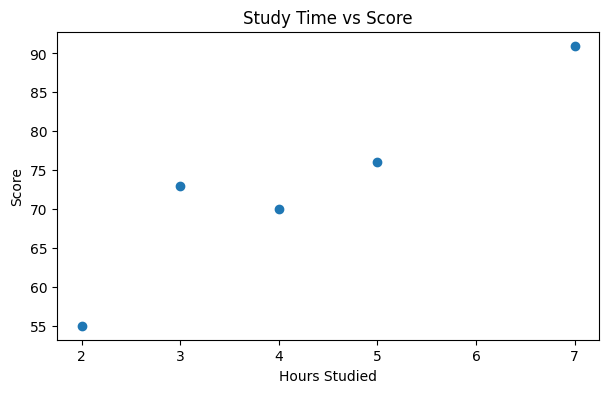

In [18]:
plt.figure(figsize=(7, 4))
plt.scatter(clean_data["Hours_Studied"], clean_data["Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Study Time vs Score")
plt.show()

### Interpreting the graph

If points tend to rise from left to right, there may be a **positive association** between study time and score.

However:

> **Correlation or visual association does not prove causation.**

Other factors could influence both variables. Good data science requires separating what the data shows from what we assume caused it.

# Part 5 - Our Machine-Learning Dataset: Iris

For the machine-learning sections, we will use the classic **Iris flower dataset** included with scikit-learn.

Each flower has four measured features:

1. sepal length,
2. sepal width,
3. petal length,
4. petal width.

The supervised-learning target is the flower species.

Using a built-in dataset lets us focus on machine-learning concepts without requiring an internet connection.

In [19]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [20]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

print("\nClass counts:")
print(df["species"].value_counts())

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 5.1 Features and Target

Suppose we want to predict the species.

We separate the dataset into:

- \(X\): the **feature matrix**, containing measurements used as inputs.
- \(y\): the **target vector**, containing the known species labels.

This distinction is fundamental to supervised learning.

A model learns an approximation of a relationship:

\[
f: X \rightarrow y
\]

After learning from historical examples, we hope the model can generalise to observations it has never seen before.

In [21]:
X = df[iris.feature_names]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (150, 4)
y shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Part 6 — Supervised Learning

## 6.1 Definition

In **supervised learning**, the training dataset contains both inputs and correct outputs.

A supervised algorithm attempts to learn a function:

\[
\hat{y} = f(X)
\]

There are two common types.

### Classification

The target is a category.

Examples:

- healthy vs diseased plant,
- spam vs legitimate email,
- flower species,
- fraud vs non-fraud.

### Regression

The target is a continuous numerical value.

Examples:

- crop yield,
- house price,
- electricity demand,
- rainfall amount.

The Iris problem is a **multiclass classification** problem because the target can take one of three species labels.

## 6.2 Why Do We Split the Data?

If we train and evaluate a model using exactly the same examples, the model may appear excellent simply because it has already seen them.

We therefore divide the observations into:

- **Training set:** used to learn model parameters.
- **Test set:** held aside and used to estimate performance on unseen data.

Here we use an 80/20 split.

`stratify=y` attempts to preserve the class proportions in both sets.

The test set should behave like an exam: **do not use the answers while studying.**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 120
Testing examples: 30


## 6.3 Feature Scaling

Features can have different numerical ranges. Algorithms that depend on distances or optimisation can be affected when one feature's scale dominates another.

**Standardisation** transforms a feature approximately as:

\[
z = \frac{x-\mu}{\sigma}
\]

where:

- \(x\) is the original value,
- \(\mu\) is the training mean,
- \(\sigma\) is the training standard deviation.

The transformed training feature has approximately mean 0 and standard deviation 1.

### Avoiding data leakage

We must calculate preprocessing parameters from the **training data**, not from the complete dataset. Otherwise information from the test set can leak into model development.

A scikit-learn **Pipeline** helps enforce the correct sequence:

**training data → scaling → model**

When predictions are requested, the same fitted transformation is applied automatically.

## 6.4 Logistic Regression

Despite its name, **logistic regression** is commonly used for classification.

For binary classification, it models a probability using the logistic function:

\[
P(y=1|x)=\frac{1}{1+e^{-z}}
\]

where \(z\) is a weighted combination of the input features.

For multiclass problems such as Iris, the method is extended to estimate probabilities across several classes.

The important beginner idea is that the model learns **weights** describing how features contribute to the predicted classes.

In [23]:
supervised_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

supervised_model.fit(X_train, y_train)

y_pred = supervised_model.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test.to_numpy()[:10])

First 10 predictions: [0 2 1 1 0 1 0 0 2 1]
First 10 actual labels: [0 2 1 1 0 1 0 0 2 1]


# Part 7 — Evaluating a Classification Model

A prediction alone does not tell us whether a model is useful. We need **evaluation metrics**.

## 7.1 Accuracy

\[
Accuracy = \frac{\text{Correct Predictions}}{\text{All Predictions}}
\]

Accuracy is intuitive, but it can be misleading when classes are highly imbalanced.

Imagine 99% of transactions are legitimate. A model that predicts `"legitimate"` for everything obtains 99% accuracy while detecting no fraud.

## 7.2 Precision

\[
Precision = \frac{TP}{TP+FP}
\]

Precision asks:

> Of the observations predicted as this class, how many were actually correct?

## 7.3 Recall

\[
Recall = \frac{TP}{TP+FN}
\]

Recall asks:

> Of all the observations that truly belonged to this class, how many did the model find?

## 7.4 F1-score

\[
F1 = 2\frac{Precision \times Recall}{Precision+Recall}
\]

F1 balances precision and recall through their harmonic mean.

Which metric matters most depends on the real-world cost of different errors.

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Accuracy: 0.933

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 7.5 Confusion Matrix

A **confusion matrix** shows which true classes were predicted as which classes.

Rows represent actual classes and columns represent predicted classes. Values on the main diagonal are correct predictions; off-diagonal values are mistakes.

This is useful because two models with similar overall accuracy can make very different kinds of errors.

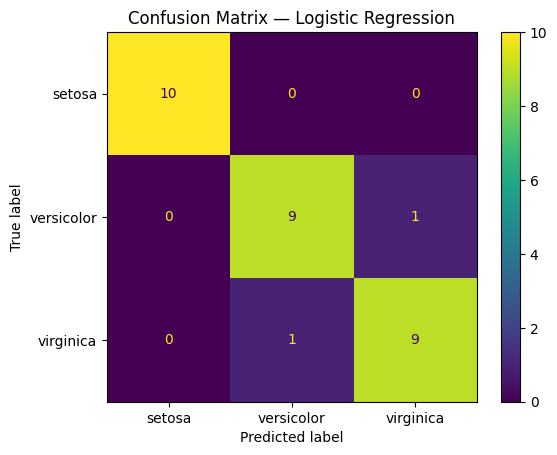

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## 7.6 Generalisation and Overfitting

The goal of machine learning is not to memorise the training dataset. It is to **generalise** to new observations.

### Underfitting

The model is too simple to capture important patterns. It performs poorly even on training data.

### Overfitting

The model learns the training examples — including noise or accidental details — too closely. Training performance may be excellent while performance on unseen data is substantially worse.

A useful conceptual picture is:

- **Underfit:** model has not learned enough.
- **Good fit:** model captures patterns that transfer to new data.
- **Overfit:** model has memorised too much of the training-specific detail.

The train/test split gives us one basic way to check generalisation.

In [26]:
train_accuracy = supervised_model.score(X_train, y_train)
test_accuracy = supervised_model.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Test accuracy:     {test_accuracy:.3f}")

Training accuracy: 0.958
Test accuracy:     0.933


### Exercise 2 — Think Like a Data Scientist

Discuss with another participant:

1. If training accuracy is 100% and test accuracy is 65%, what might be happening?
2. Why should we not scale the full dataset before splitting it?
3. For disease screening, when might **recall** be more important than accuracy?
4. If one class has only 10 examples while another has 10,000, why might accuracy be misleading?

Write your thoughts below.

In [27]:
# Write your answers as comments.

# 1.
# 2.
# 3.
# 4.

# Part 8 - Unsupervised Learning

## 8.1 Definition

In **unsupervised learning**, the algorithm receives input features but no target labels.

Instead of learning:

\[
X \rightarrow y
\]

the algorithm investigates the structure of \(X\) itself.

Common unsupervised tasks include:

- **clustering** — grouping similar observations,
- **dimensionality reduction** — representing many variables with fewer dimensions,
- **anomaly detection** — identifying unusual observations,
- **representation learning** — learning useful structures from raw data.

### Important distinction

A cluster is **not automatically a real-world class**.

An algorithm may divide observations according to geometry in feature space, but humans must investigate whether those groups are meaningful in the domain.

# Part 9 - K-Means Clustering

**K-Means** divides observations into \(K\) clusters.

Conceptually, the algorithm repeats the following process:

1. Choose \(K\) initial cluster centres called **centroids**.
2. Assign each observation to its nearest centroid.
3. Recalculate each centroid as the mean of its assigned observations.
4. Repeat until the assignments/centroids stabilise.

The algorithm tries to minimise the within-cluster sum of squared distances:

\[
\sum_{k=1}^{K}\sum_{x_i \in C_k} ||x_i-\mu_k||^2
\]

where \(C_k\) is cluster \(k\) and \(\mu_k\) is its centroid.

### Why scaling matters

K-Means uses distances. If one feature is measured on a much larger numerical scale, it may dominate those distances. We therefore standardise the features first.

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clustered_df = df.copy()
clustered_df["cluster"] = clusters

clustered_df[["species", "cluster"]].head(10)

,species,cluster
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
5,setosa,1
6,setosa,1
7,setosa,1
8,setosa,1
9,setosa,1


## 9.1 Visualising the Clusters

Our data has four features, but a normal scatter plot displays only two dimensions at once. We will visualise petal length against petal width and colour each point according to its K-Means cluster.

Remember: the clustering algorithm used **all four scaled features**. The graph is only a two-dimensional view of that result.

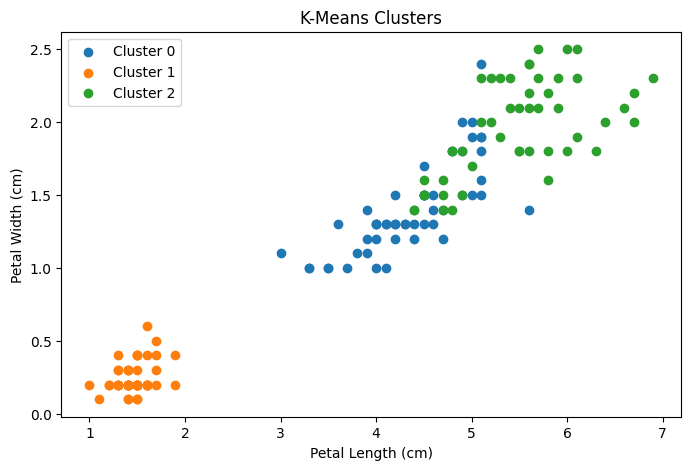

In [29]:
plt.figure(figsize=(8, 5))

for cluster_id in sorted(clustered_df["cluster"].unique()):
    subset = clustered_df[clustered_df["cluster"] == cluster_id]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clusters")
plt.legend()
plt.show()

## 9.2 Choosing the Number of Clusters

K-Means requires us to choose \(K\). In a real unsupervised problem, the correct number of groups may be unknown.

One useful metric is the **silhouette score**. It considers both:

- how close an observation is to members of its own cluster (**cohesion**),
- how separated it is from other clusters (**separation**).

The score ranges approximately from -1 to 1:

- closer to **1**: clusters are relatively compact and separated,
- around **0**: clusters overlap,
- below **0**: some observations may fit another cluster better.

A high silhouette score does **not** prove that the clusters have real-world meaning. Domain interpretation remains necessary.

In [30]:
results = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append((k, score))

silhouette_results = pd.DataFrame(
    results,
    columns=["Number of Clusters (k)", "Silhouette Score"]
)

silhouette_results

,Number of Clusters (k),Silhouette Score
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079


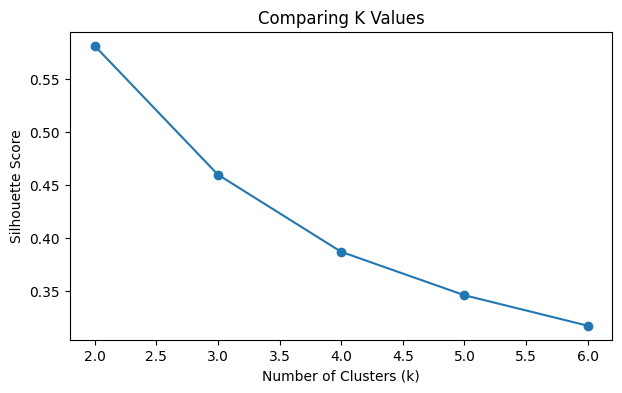

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(
    silhouette_results["Number of Clusters (k)"],
    silhouette_results["Silhouette Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Comparing K Values")
plt.show()

## 9.3 Comparing Clusters with Known Labels — For Learning Only

Because Iris happens to contain species labels, we can compare the discovered clusters with those labels after clustering.

This is useful educationally, but remember:

- K-Means did **not** use species labels during training.
- Cluster IDs such as `0`, `1`, and `2` have no intrinsic meaning.
- A cluster does not have to correspond exactly to a human-defined class.

In a genuinely unlabeled dataset, we would not have this table of known classes.

In [32]:
comparison = pd.crosstab(
    clustered_df["species"],
    clustered_df["cluster"],
    rownames=["Known Species"],
    colnames=["K-Means Cluster"]
)

comparison

K-Means Cluster,0,1,2
Known Species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


# Part 10 — Supervised vs Unsupervised Learning

| Question | Supervised Learning | Unsupervised Learning |
|---|---|---|
| Are target labels provided? | Yes | No |
| Main goal | Predict an outcome | Discover structure |
| Example tasks | Classification, regression | Clustering, dimensionality reduction |
| Example algorithms | Logistic Regression, Decision Trees, Random Forests | K-Means, DBSCAN, PCA |
| Typical evaluation | Accuracy, precision, recall, F1, MAE, RMSE | Silhouette score, stability, domain usefulness |

### Example from agriculture

Suppose we have sugarcane field data containing rainfall, variety, age, soil properties, sucrose measurements, and final yield.

If historical yield is known and we train a model to predict it, this is **supervised regression**.

If we have no outcome label and instead group fields with similar agronomic characteristics, this is **unsupervised clustering**.

The same dataset can therefore support different machine-learning questions.

# Part 11 — A Responsible Machine-Learning Workflow

A basic workflow can be summarised as:

### 1. Define the problem
What decision or question are we trying to support?

### 2. Understand the data
Where did it come from? What does each variable mean? Who or what is represented?

### 3. Clean and prepare
Handle missing values, duplicates, types, categories, scaling, and invalid records.

### 4. Explore
Use statistics and visualisations to understand patterns and potential problems.

### 5. Separate training and evaluation data
Protect unseen data from leakage.

### 6. Train a baseline model
Start with something understandable before automatically reaching for a highly complex model.

### 7. Evaluate appropriately
Choose metrics based on the consequences of errors.

### 8. Interpret errors
Ask where the model fails, not only how often.

### 9. Consider fairness, privacy, and context
A technically accurate system can still be harmful if the dataset excludes important groups, contains sensitive information, or is deployed outside the environment for which it was designed.

### 10. Monitor after deployment
Real-world data can change. A model that performed well during development may degrade over time.

Machine learning is therefore not simply:

> `model.fit()` → finished.

It is an iterative process involving data, people, assumptions, evaluation, and responsible decision-making.

# Part 12 — Mini Challenge

You are now the data scientist.

Using the Iris dataset:

1. Select any **two features**.
2. Create a scatter plot and describe the pattern you observe.
3. Train the supervised classifier using only those two features.
4. Calculate its test accuracy.
5. Run K-Means with `k=2`, `k=3`, and `k=4`.
6. Calculate the silhouette score for each value of `k`.
7. Explain why the best clustering value does not necessarily reveal the “true” number of biological species.
8. Write one example of how supervised or unsupervised learning could solve a problem in your community.

### Bonus questions

- What could happen if your training data is biased?
- What information would you need before deploying a model?
- How would you explain your model's limitations to a non-technical decision-maker?

In [33]:
# MINI CHALLENGE WORKSPACE

# Step 1: choose two features
selected_features = [
    # "sepal length (cm)",
    # "petal length (cm)"
]

# Continue your analysis below.

# Part 13 — Key Vocabulary

**Algorithm** — A defined computational procedure for solving a problem.

**Dataset** — A structured collection of observations.

**Feature** — An input variable used by a model.

**Target / Label** — The outcome a supervised model learns to predict.

**Training** — The process through which a model learns parameters from data.

**Inference** — Using a trained model to make predictions on new observations.

**Classification** — Predicting a categorical outcome.

**Regression** — Predicting a continuous numerical outcome.

**Clustering** — Grouping observations according to similarity without known target labels.

**Preprocessing** — Transforming raw data into a form suitable for analysis or modelling.

**Scaling** — Transforming numerical variables so their magnitudes are more comparable.

**Data leakage** — Information that should be unavailable during training accidentally influences the model.

**Overfitting** — Learning training-specific patterns that do not generalise well.

**Generalisation** — A model's ability to perform well on unseen data.

**Metric** — A quantitative measure used to evaluate model behaviour.

**Bias in data** — Systematic distortion or underrepresentation in the data that can lead to misleading or unfair conclusions.

# Part 14 — Reflection

Before leaving the session, answer these questions in your own words:

1. What is one new Python concept you learned?
2. Why is data cleaning important?
3. What is the difference between a feature and a target?
4. What is the key difference between supervised and unsupervised learning?
5. Why do we keep test data separate from training data?
6. What does a confusion matrix tell us?
7. Why do we scale data before K-Means?
8. What is one AI problem in Eswatini that you would like to investigate?

The goal of today's workshop is not to memorise every command. It is to understand the **logic of the workflow** well enough that you can continue experimenting after Indaba X.

## Keep building

A small notebook can become a real AI project:

**Question → Dataset → Exploration → Model → Evaluation → Improvement → Impact**

Your next step is to choose a problem you care about and start asking what data would be needed to investigate it responsibly.